# Reglas de Asociación

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

try:
    df = pd.read_csv('../movies_2026.csv', encoding='latin-1')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: movies_2026.csv not found.")

Dataset loaded successfully.


**Preparando el entorno y cargando datos**

In [ ]:
cols = ['genres', 'budget', 'revenue', 'voteAvg', 'popularity']
df_rules = df[cols].dropna().copy()

df_rules = df_rules[(df_rules['budget'] > 1000) & (df_rules['revenue'] > 1000)]

print(f"Filas después de limpieza: {len(df_rules)}")

# Discretización en bins
df_rules['Budget_Bin'] = pd.qcut(df_rules['budget'], q=3, labels=['Budget_Low', 'Budget_Med', 'Budget_High'])
df_rules['Revenue_Bin'] = pd.qcut(df_rules['revenue'], q=3, labels=['Revenue_Low', 'Revenue_Med', 'Revenue_High'])
df_rules['Rating_Bin'] = pd.cut(df_rules['voteAvg'], bins=[0, 5, 7, 10], labels=['Rating_Bad', 'Rating_Avg', 'Rating_Good'])
df_rules['Pop_Bin'] = pd.qcut(df_rules['popularity'], q=2, labels=['Pop_Low', 'Pop_High'])

print("Datos discretizados:")
display(df_rules[['Budget_Bin', 'Revenue_Bin', 'Rating_Bin', 'Pop_Bin']].head())

Rows remaining after cleaning zeros: 4389
Discretized Data Head:


,Budget_Bin,Revenue_Bin,Rating_Bin,Pop_Bin
429,Budget_Low,Revenue_Low,Rating_Good,Pop_High
1009,Budget_Med,Revenue_Low,Rating_Good,Pop_High
1230,Budget_Med,Revenue_Med,Rating_Good,Pop_High
1231,Budget_Med,Revenue_Low,Rating_Avg,Pop_High
1296,Budget_Low,Revenue_Low,NaN,Pop_Low


**Limpieza y discretización de variables numéricas**

In [ ]:
genres_dummies = df_rules['genres'].str.get_dummies(sep='|')

budget_dummies = pd.get_dummies(df_rules['Budget_Bin'])
revenue_dummies = pd.get_dummies(df_rules['Revenue_Bin'])
rating_dummies = pd.get_dummies(df_rules['Rating_Bin'])
pop_dummies = pd.get_dummies(df_rules['Pop_Bin'])

basket = pd.concat([genres_dummies, budget_dummies, revenue_dummies, rating_dummies, pop_dummies], axis=1)
basket = basket.astype(bool)

print(f"Matriz de transacciones: {basket.shape}")
display(basket.head())

Transaction Matrix Shape: (4389, 30)


,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,...,Budget_Med,Budget_High,Revenue_Low,Revenue_Med,Revenue_High,Rating_Bad,Rating_Avg,Rating_Good,Pop_Low,Pop_High
429,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True
1009,True,False,False,False,False,False,True,False,False,False,...,True,False,True,False,False,False,False,True,False,True
1230,False,False,False,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,True
1231,False,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,False,False,True
1296,False,False,False,True,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False


**Creación de matriz de transacciones**

In [ ]:
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)
rules = rules.sort_values(by='lift', ascending=False)

print("Top 10 Reglas de Asociación por Lift:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Found 364 frequent itemsets.
Top 10 Association Rules by Lift:


,antecedents,consequents,support,confidence,lift
272,"frozenset({Pop_High, Family})",frozenset({Animation}),0.053087,0.602067,7.507025
277,frozenset({Animation}),"frozenset({Pop_High, Family})",0.053087,0.661932,7.507025
276,frozenset({Family}),"frozenset({Pop_High, Animation})",0.053087,0.394247,6.554357
273,"frozenset({Pop_High, Animation})",frozenset({Family}),0.053087,0.882576,6.554357
29,frozenset({Animation}),frozenset({Family}),0.068353,0.852273,6.329315
28,frozenset({Family}),frozenset({Animation}),0.068353,0.507614,6.329315
1234,"frozenset({Pop_High, Action, Budget_High})","frozenset({Revenue_High, Adventure})",0.057188,0.530655,4.305077
1247,"frozenset({Revenue_High, Adventure})","frozenset({Pop_High, Action, Budget_High})",0.057188,0.463956,4.305077
1240,"frozenset({Pop_High, Budget_High, Adventure})","frozenset({Action, Revenue_High})",0.057188,0.542117,4.102327
1241,"frozenset({Action, Revenue_High})","frozenset({Pop_High, Budget_High, Adventure})",0.057188,0.432759,4.102327


**Generación de reglas de asociación**

Rules with Confidence > 50%:


,antecedents,consequents,support,confidence,lift
272,"frozenset({Pop_High, Family})",frozenset({Animation}),0.053087,0.602067,7.507025
277,frozenset({Animation}),"frozenset({Pop_High, Family})",0.053087,0.661932,7.507025
273,"frozenset({Pop_High, Animation})",frozenset({Family}),0.053087,0.882576,6.554357
29,frozenset({Animation}),frozenset({Family}),0.068353,0.852273,6.329315
28,frozenset({Family}),frozenset({Animation}),0.068353,0.507614,6.329315


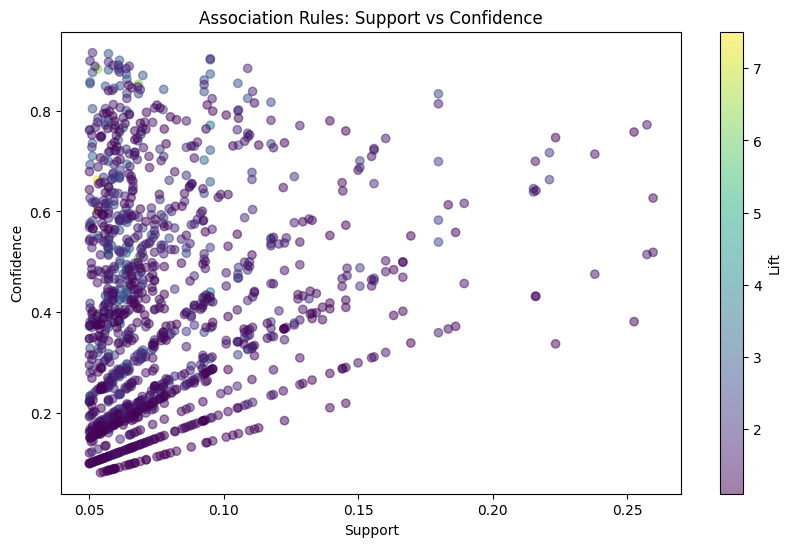

In [ ]:
high_conf_rules = rules[rules['confidence'] > 0.5]

print("Reglas con Confianza > 50%:")
display(high_conf_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], alpha=0.5, c=rules['lift'], cmap='viridis')
plt.colorbar(label='Lift')
plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.title('Reglas de Asociación: Soporte vs Confianza')
plt.show()

**Análisis y visualización de reglas de alta confianza**